# Principal Component Analysis

## Task

- In the Portland Housing Prices/Sales dataset Jul 2020 - Jul 2021, determine if there is a multicollinearity problem.
- Perform a principal component analysis
- Create a linear model from PCA and compare the model to the previous exercise

# Data loading

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [36]:
data = pd.read_csv ("..\dataset\portland_filtered.csv",  sep=';')

# Analysis
- show data
- solve NaN values
- display basic data statistics
- show correlation matrix

First 10 rows:
   bathrooms  bedrooms  livingArea  age    price
0          3         5        3470    7  1165000
1          4         5        3374   85  1050000
2          3         3        3265   20   442500
3          3         3        3192   36   765000
4          3         4        3157   73   815000
5          4         5        2969    7   620000
6          2         4        2964  113   570000
7          3         4        2929    6   620000
8          3         4        2908   19   660000
9          3         4        2853   29   710000

Dataset shape after cleaning: (100, 5)

Basic statistics:
        bathrooms    bedrooms   livingArea        age         price
count  100.000000  100.000000   100.000000  100.00000  1.000000e+02
mean     2.380000    3.260000  1974.080000   49.88000  5.196074e+05
std      0.838228    0.860115   663.629851   32.77973  1.722241e+05
min      1.000000    1.000000   766.000000    3.00000  1.650000e+05
25%      2.000000    3.000000  1530.000000   20

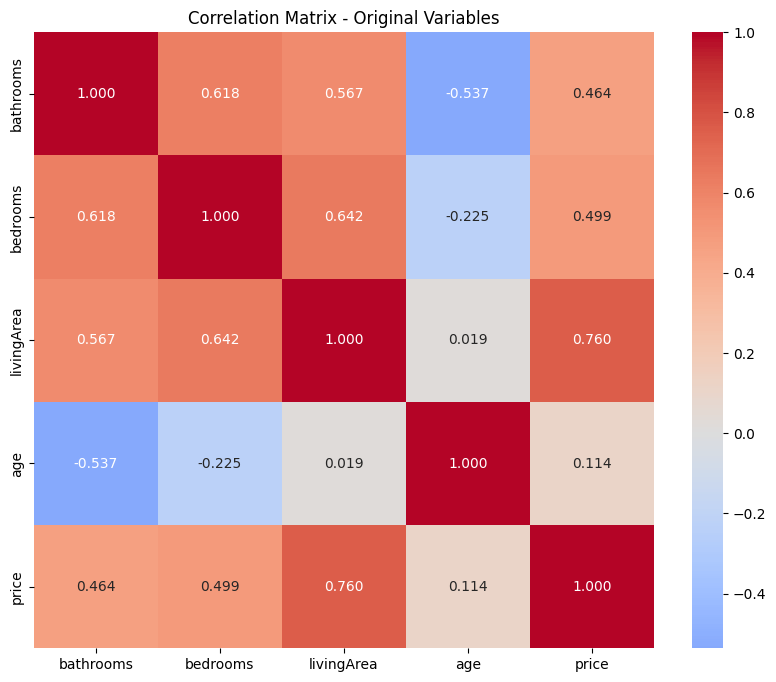

In [44]:
print("First 10 rows:")
print(data.head(10))

# Solve NaN values
cols_to_use = ['bathrooms', 'bedrooms', 'livingArea', 'age', 'price']
data_clean = data[cols_to_use].dropna()
print("\nDataset shape after cleaning:", data_clean.shape)

# Display basic data statistics
print("\nBasic statistics:")
print(data_clean.describe())

# Show correlation matrix
print("\nCorrelation matrix:")
correlation_matrix = data_clean.corr()
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix - Original Variables')
plt.show()

# Data preparation
- select X variables bathrooms', 'bedrooms', 'livingArea','age','price'
- standardize the variables

In [45]:
X = data_clean[['bathrooms', 'bedrooms', 'livingArea', 'age']].copy()
y = data_clean['price'].copy()

# Standardize the variables
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std



# Display the VIF for each variable

In [46]:
# Display the VIF for each variable
print("\nVIF (Variance Inflation Factor):")
vif_results = []
for i in range(X_scaled.shape[1]):
    X_temp = X_scaled.drop(X_scaled.columns[i], axis=1)
    y_temp = X_scaled.iloc[:, i]
    
    model_vif = LinearRegression()
    model_vif.fit(X_temp, y_temp)
    r2 = model_vif.score(X_temp, y_temp)
    
    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_results.append({'Feature': X.columns[i], 'VIF': vif})

vif_data = pd.DataFrame(vif_results)
print(vif_data)


VIF (Variance Inflation Factor):
      Feature       VIF
0   bathrooms  2.857373
1    bedrooms  2.036889
2  livingArea  2.303777
3         age  1.798314


# PCA
- Perform PCA
- show correlation matrix


Check X_pca for NaN:
0    0
1    0
2    0
3    0
dtype: int64

Correlation Matrix of Principal Components:
              PC1           PC2           PC3           PC4
PC1  1.000000e+00  6.943583e-16 -1.259082e-15 -4.510885e-16
PC2  6.943583e-16  1.000000e+00  2.341246e-16 -5.790390e-16
PC3 -1.259082e-15  2.341246e-16  1.000000e+00  1.249132e-15
PC4 -4.510885e-16 -5.790390e-16  1.249132e-15  1.000000e+00


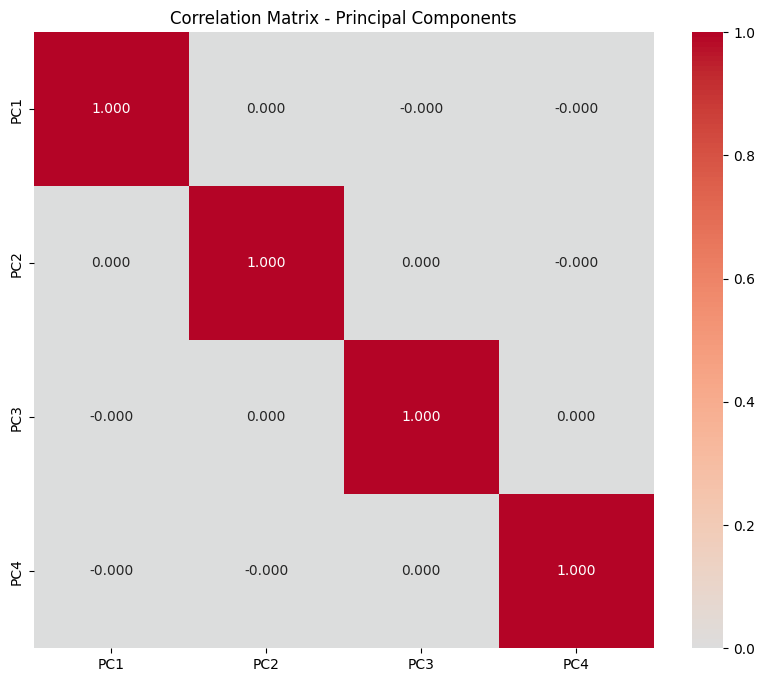

In [49]:
cov_matrix = np.cov(X_scaled.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Transform to principal components
X_pca = np.dot(X_scaled.values, eigenvectors)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(eigenvalues))])

print("\nCheck X_pca for NaN:")
print(pd.DataFrame(X_pca).isnull().sum())

# Show correlation matrix
print("\nCorrelation Matrix of Principal Components:")
pca_corr = X_pca_df.corr()
print(pca_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(pca_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix - Principal Components')
plt.show()


# Linear model
- Create and train a Linear Model for PCA variables
- Show R2 and RMSE

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model_pca = LinearRegression()
model_pca.fit(X_train, y_train)
y_pred = model_pca.predict(X_test)

# Show R2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nLinear Model - PCA Variables:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")


Linear Model - PCA Variables:
R² Score: 0.4425
RMSE: $148,294.07
